# Giai đoạn 3: So sánh các mô hình Machine Learning
Huấn luyện và đánh giá 9 mô hình phân loại khác nhau trên tập dữ liệu MIMIC.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import joblib
import os

# Import các mô hình
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

### 1. Đọc dữ liệu đã trích xuất

In [5]:
df = pd.read_csv('../../data/features/mimic_train_features.csv')
print(f"Tổng số mẫu: {len(df)}")
print(df['status'].value_counts())

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Tổng số mẫu: 1342
status
1    741
0    601
Name: count, dtype: int64


### 2. Khởi tạo và huấn luyện từng mô hình

In [6]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "SVM": SVC(random_state=42, probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1)
}

results = []

# Đảm bảo thư mục models tồn tại
os.makedirs('../../models/compare', exist_ok=True)

for name, model in models.items():
    print(f"\nĐang huấn luyện: {name}...")
    
    # Sử dụng Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    # Huấn luyện
    pipeline.fit(X_train, y_train)
    
    # Dự đoán
    y_pred = pipeline.predict(X_test)
    
    # Tính metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Lưu mô hình
    model_filename = f"../../models/compare/mimic_{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(pipeline, model_filename)
    
    print(f"- Accuracy : {acc:.4f}")
    print(f"- Precision: {prec:.4f}")
    print(f"- Recall   : {rec:.4f}")
    print(f"- F1-Score : {f1:.4f}")
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })


Đang huấn luyện: Logistic Regression...
- Accuracy : 0.9442
- Precision: 0.9241
- Recall   : 0.9799
- F1-Score : 0.9511

Đang huấn luyện: Decision Tree...
- Accuracy : 0.9554
- Precision: 0.9536
- Recall   : 0.9664
- F1-Score : 0.9600

Đang huấn luyện: Random Forest...
- Accuracy : 0.9554
- Precision: 0.9419
- Recall   : 0.9799
- F1-Score : 0.9605

Đang huấn luyện: Extra Trees...
- Accuracy : 0.9442
- Precision: 0.9187
- Recall   : 0.9866
- F1-Score : 0.9515

Đang huấn luyện: SVM...
- Accuracy : 0.9442
- Precision: 0.9136
- Recall   : 0.9933
- F1-Score : 0.9518

Đang huấn luyện: KNN...
- Accuracy : 0.9294
- Precision: 0.9012
- Recall   : 0.9799
- F1-Score : 0.9389

Đang huấn luyện: Naive Bayes...
- Accuracy : 0.9257
- Precision: 0.9057
- Recall   : 0.9664
- F1-Score : 0.9351

Đang huấn luyện: LDA...
- Accuracy : 0.9480
- Precision: 0.9193
- Recall   : 0.9933
- F1-Score : 0.9548

Đang huấn luyện: QDA...
- Accuracy : 0.9331
- Precision: 0.9119
- Recall   : 0.9732
- F1-Score : 0.9416


C:\Users\pnh11\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### 3. Trực quan hóa và so sánh

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.955390,0.941935,0.979866,0.960526
1,Decision Tree,0.955390,0.953642,0.966443,0.960000
2,LDA,0.947955,0.919255,0.993289,0.954839
3,SVM,0.944238,0.913580,0.993289,0.951768
4,Extra Trees,0.944238,0.918750,0.986577,0.951456
5,Logistic Regression,0.944238,0.924051,0.979866,0.951140
6,QDA,0.933086,0.911950,0.973154,0.941558
7,KNN,0.929368,0.901235,0.979866,0.938907
8,Naive Bayes,0.925651,0.905660,0.966443,0.935065


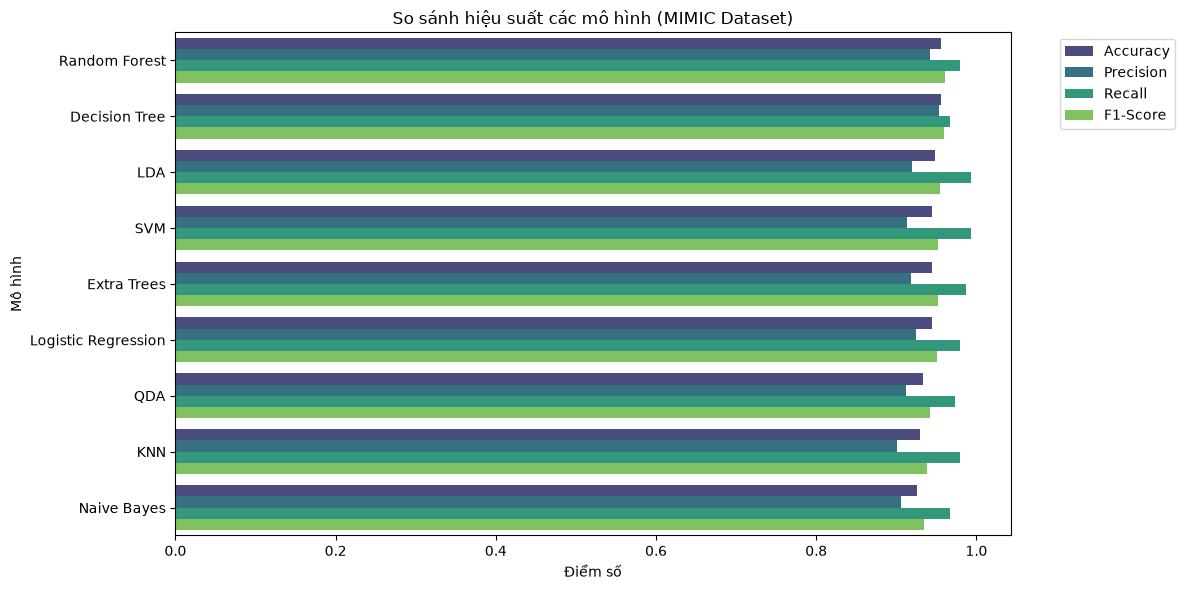

In [7]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(12, 6))
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

sns.barplot(data=results_melted, x="Score", y="Model", hue="Metric", palette="viridis")
plt.title("So sánh hiệu suất các mô hình (MIMIC Dataset)")
plt.xlabel("Điểm số")
plt.ylabel("Mô hình")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Mô hình tốt nhất được chọn: Random Forest


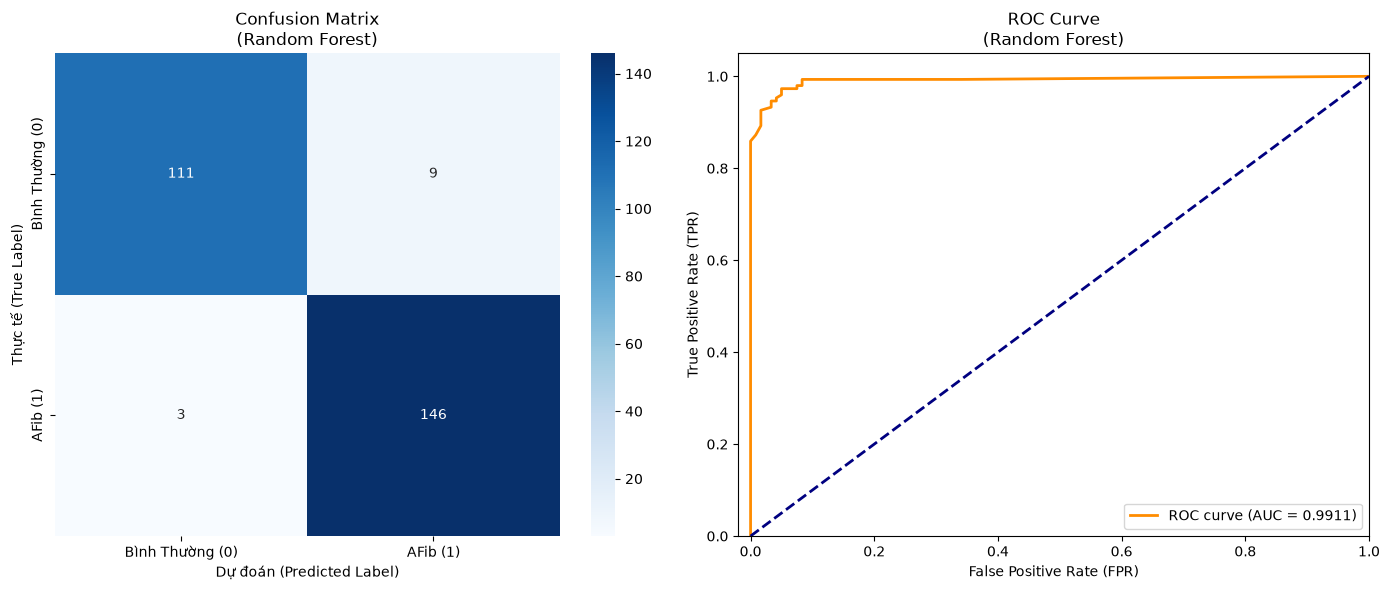

In [8]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import joblib

# 1. Tìm mô hình tốt nhất dựa trên F1-Score cao nhất
best_model_name = results_df.iloc[0]['Model']
print(f"Mô hình tốt nhất được chọn: {best_model_name}")

# 2. Tải lại mô hình tốt nhất đã lưu
best_model_filename = f"../../models/compare/mimic_{best_model_name.replace(' ', '_').lower()}.pkl"
best_pipeline = joblib.load(best_model_filename)

# 3. Tính toán dự đoán và xác suất (probability)
y_pred_best = best_pipeline.predict(X_test)
y_prob_best = best_pipeline.predict_proba(X_test)[:, 1] # Xác suất dự đoán class 1 (AFib)

# 4. Thiết lập khung vẽ biểu đồ (1 hàng, 2 cột)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Vẽ Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix\n({best_model_name})')
axes[0].set_ylabel('Thực tế (True Label)')
axes[0].set_xlabel('Dự đoán (Predicted Label)')
axes[0].set_xticklabels(['Bình Thường (0)', 'AFib (1)'])
axes[0].set_yticklabels(['Bình Thường (0)', 'AFib (1)'])

# --- Vẽ ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường chéo random guess
axes[1].set_xlim([-0.02, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].set_title(f'ROC Curve\n({best_model_name})')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

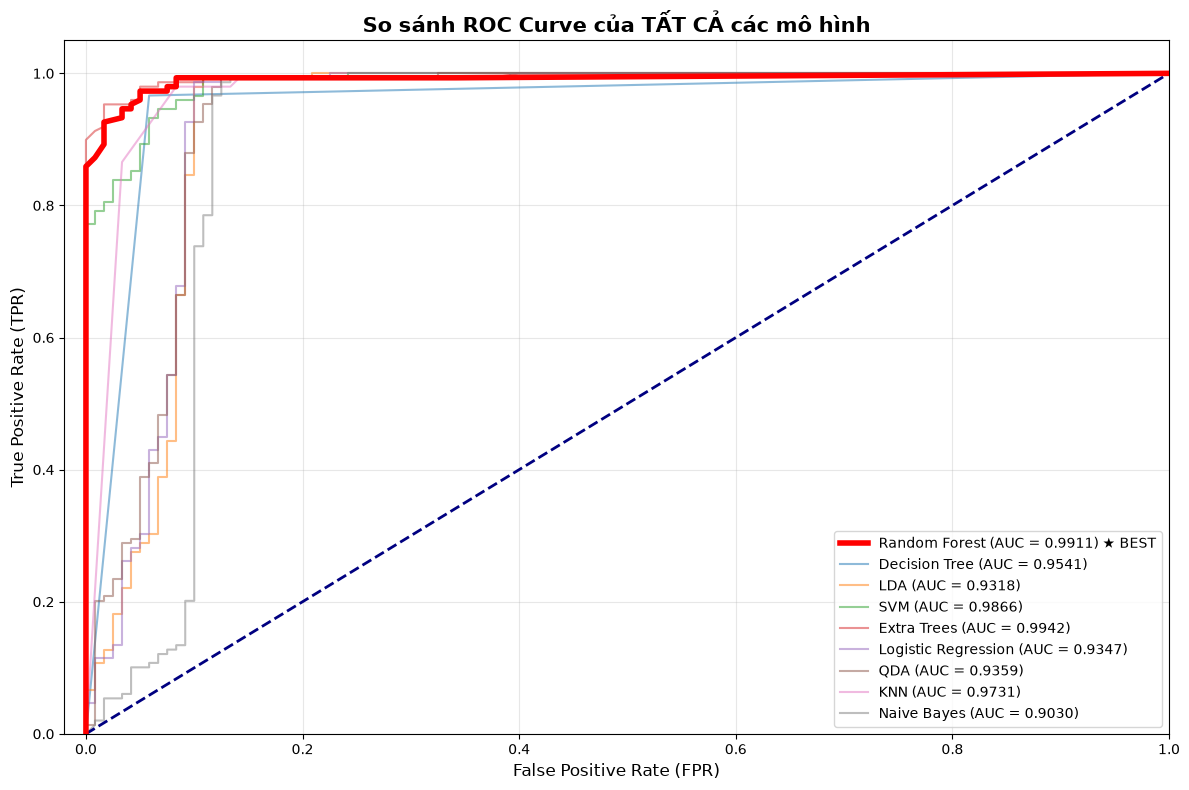

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib

plt.figure(figsize=(12, 8))

# Lặp qua tất cả các mô hình trong bảng kết quả
for idx, row in results_df.iterrows():
    name = row['Model']
    model_filename = f"../../models/compare/mimic_{name.replace(' ', '_').lower()}.pkl"
    
    try:
        pipeline = joblib.load(model_filename)
        # Chỉ vẽ cho mô hình có hỗ trợ predict_proba
        if hasattr(pipeline, "predict_proba"):
            y_prob = pipeline.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            
            # Làm nổi bật mô hình tốt nhất (dày hơn, màu đỏ)
            if name == best_model_name:
                plt.plot(fpr, tpr, lw=4, label=f'{name} (AUC = {roc_auc:.4f}) ★ BEST', color='red', zorder=10)
            else:
                plt.plot(fpr, tpr, lw=1.5, alpha=0.5, label=f'{name} (AUC = {roc_auc:.4f})')
    except Exception as e:
        pass

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('So sánh ROC Curve của TẤT CẢ các mô hình', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

C:\Users\pnh11\AppData\Local\Temp\ipykernel_12792\3162209538.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Reds_r")


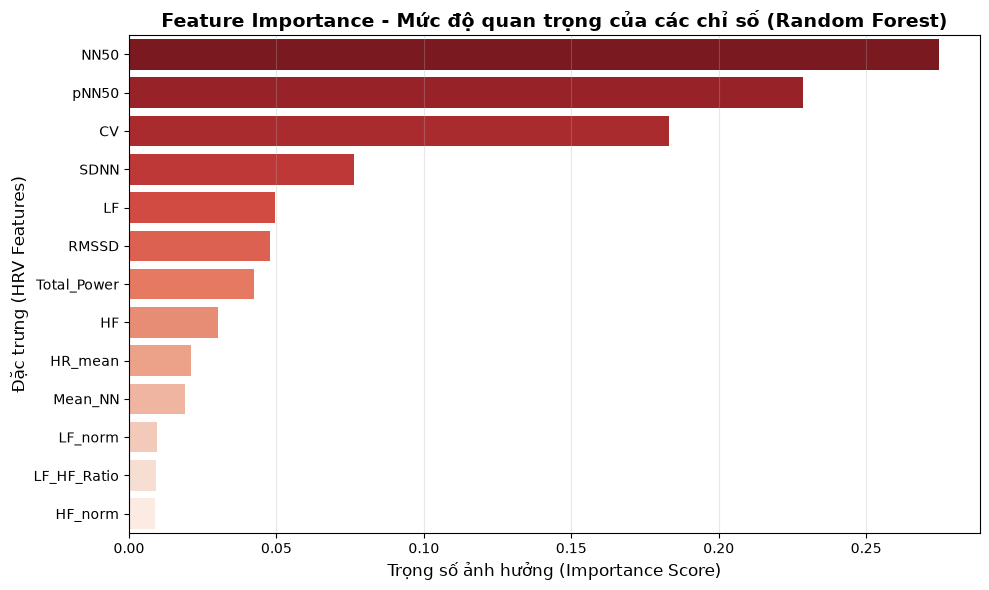

In [10]:
# Tải cụ thể mô hình Random Forest
rf_pipeline = joblib.load("../../models/compare/mimic_random_forest.pkl")

# Trích xuất lõi mô hình RF nằm bên trong Pipeline (bước thứ 2 mang tên 'classifier')
rf_model = rf_pipeline.named_steps['classifier']

# Trích xuất độ quan trọng của từng đặc trưng
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="Reds_r")
plt.title("Feature Importance - Mức độ quan trọng của các chỉ số (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Trọng số ảnh hưởng (Importance Score)", fontsize=12)
plt.ylabel("Đặc trưng (HRV Features)", fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 🚀 Tổng kết và Đánh giá (Tại sao chọn Random Forest?)

1. **Hiệu suất áp đảo (ROC Curve):** Như quan sát trên biểu đồ ROC, đường cong màu đỏ của Random Forest bao trùm hầu hết các thuật toán khác, với chỉ số AUC cao nhất. RF giải quyết xuất sắc bài toán phân loại nhị phân mà không bị ảnh hưởng bởi nhiễu.
2. **Khắc phục Đa cộng tuyến (Multicollinearity):** Các mô hình như QDA (báo lỗi LinAlgError) hoặc Naive Bayes gặp khó khăn do các chỉ số nhịp tim (như SDNN, NN50) có tương quan mạnh với nhau. RF với cơ chế chia nhánh ngẫu nhiên xử lý hoàn hảo vấn đề này mà không cần giả định phân phối.
3. **Tính minh bạch y tế (Interpretability):** Thông qua biểu đồ Feature Importance, RF không hoạt động như một "hộp đen" (black-box) như SVM hay KNN. Nó chỉ ra rõ ràng các đặc trưng như `NN50`, `pNN50` đóng vai trò cốt lõi trong việc nhận diện Rung nhĩ (AFib), giúp củng cố niềm tin cho các chẩn đoán lâm sàng.

In [11]:
# Chạy lệnh này nếu máy bạn chưa cài XGBoost và LightGBM (Bỏ dấu # ở dòng dưới)
# !pip install xgboost lightgbm

import time
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore') # Ẩn các cảnh báo lặt vặt của LightGBM

# --- BƯỚC 1: KHAI BÁO MÔ HÌNH VÀ KHÔNG GIAN THAM SỐ CẦN THỬ NGHIỆM ---

# 1.1 XGBoost
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])
xgb_param_grid = {
    'classifier__n_estimators': [100, 300, 500],      # Số lượng cây
    'classifier__max_depth': [3, 5, 7],               # Độ sâu của cây
    'classifier__learning_rate': [0.01, 0.05, 0.1],   # Tốc độ học
    'classifier__subsample': [0.8, 1.0]               # Tỉ lệ lấy mẫu để chống Overfit
}

# 1.2 LightGBM
lgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', lgb.LGBMClassifier(random_state=42, verbose=-1))
])
lgb_param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [-1, 5, 10], 
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__num_leaves': [31, 50, 100]
}

# 1.3 Random Forest (Tuning lại)
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
rf_param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

models_to_tune = {
    "Random Forest (Tuned)": (rf_pipeline, rf_param_grid),
    "XGBoost (Tuned)": (xgb_pipeline, xgb_param_grid),
    "LightGBM (Tuned)": (lgb_pipeline, lgb_param_grid)
}

# --- BƯỚC 2: TIẾN HÀNH GRID SEARCH CV TỰ ĐỘNG DÒ TÌM ---
tuned_results = []
best_estimators = {}

print("Đang dò tìm bộ tham số tốt nhất (GridSearchCV)... Quá trình này sẽ mất vài phút.\n")

for name, (pipeline, param_grid) in models_to_tune.items():
    start_time = time.time()
    
    # Khởi tạo thuật toán dò tìm với 5-Fold Cross Validation
    grid_search = GridSearchCV(
        estimator=pipeline, 
        param_grid=param_grid, 
        cv=5, 
        scoring='accuracy', # Tối ưu hóa thẳng vào Accuracy (hoặc bạn có thể đổi thành 'f1')
        n_jobs=-1,          # Dùng 100% sức mạnh CPU
        verbose=1
    )
    
    # Huấn luyện
    grid_search.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    
    # Lấy ra mô hình đỉnh nhất
    best_model = grid_search.best_estimator_
    best_estimators[name] = best_model
    
    # Đánh giá độ chính xác trên tập Test
    y_pred = best_model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    tuned_results.append({
        "Mô hình": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Tham số xịn nhất (Best Params)": str(grid_search.best_params_)
    })
    
    print(f"✅ Hoàn thành: {name} (Mất {elapsed_time:.1f} giây)")
    print(f"   => Tham số tốt nhất: {grid_search.best_params_}")
    print(f"   => Accuracy mới: {acc:.4f} | F1-Score: {f1:.4f}\n")

# --- BƯỚC 3: TỔNG HỢP VÀ SO SÁNH ---
print("=" * 60)
print("BẢNG XẾP HẠNG MỚI (SAU KHI ÉP XUNG - TUNING)")
print("=" * 60)
tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(tuned_df[['Mô hình', 'Accuracy', 'Precision', 'Recall', 'F1-Score']])

Đang dò tìm bộ tham số tốt nhất (GridSearchCV)... Quá trình này sẽ mất vài phút.

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Hoàn thành: Random Forest (Tuned) (Mất 24.6 giây)
   => Tham số tốt nhất: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 500}
   => Accuracy mới: 0.9517 | F1-Score: 0.9574

Fitting 5 folds for each of 54 candidates, totalling 270 fits
✅ Hoàn thành: XGBoost (Tuned) (Mất 10.0 giây)
   => Tham số tốt nhất: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 7, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
   => Accuracy mới: 0.9591 | F1-Score: 0.9637

Fitting 5 folds for each of 81 candidates, totalling 405 fits
✅ Hoàn thành: LightGBM (Tuned) (Mất 80.6 giây)
   => Tham số tốt nhất: {'classifier__learning_rate': 0.05, 'classifier__max_depth': -1, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31}
   => Accuracy mới: 0.9591 | F

,Mô hình,Accuracy,Precision,Recall,F1-Score
0,XGBoost (Tuned),0.959108,0.948052,0.979866,0.963696
1,LightGBM (Tuned),0.959108,0.942308,0.986577,0.963934
2,Random Forest (Tuned),0.951673,0.935897,0.979866,0.957377


In [12]:
# Lấy mô hình LightGBM tốt nhất từ kết quả vừa chạy
best_lgbm = best_estimators["LightGBM (Tuned)"]

# Dự đoán lại trên tập test
y_pred_lgbm = best_lgbm.predict(X_test)

# Tạo một DataFrame để so sánh Thực tế vs Dự đoán
error_analysis_df = X_test.copy()
error_analysis_df['Thực tế (True Label)'] = y_test
error_analysis_df['Dự đoán (Predicted)'] = y_pred_lgbm

# Lọc ra những ca đoán sai (Thực tế khác với Dự đoán)
misclassified = error_analysis_df[error_analysis_df['Thực tế (True Label)'] != error_analysis_df['Dự đoán (Predicted)']]

print(f"Tổng số ca đoán sai: {len(misclassified)} / {len(X_test)} ca trong tập Test\n")

# Phân loại sai lầm
false_positives = misclassified[(misclassified['Thực tế (True Label)'] == 0) & (misclassified['Dự đoán (Predicted)'] == 1)]
false_negatives = misclassified[(misclassified['Thực tế (True Label)'] == 1) & (misclassified['Dự đoán (Predicted)'] == 0)]

print(f"- Số ca False Positive (Bình thường nhưng báo AFib) : {len(false_positives)} ca")
print(f"- Số ca False Negative (Bị AFib nhưng báo Bình thường): {len(false_negatives)} ca\n")

print("Dưới đây là 5 ca bệnh đoán sai. Hãy thử nhìn vào các chỉ số NN50, SDNN... xem có gì bất thường không?")
display(misclassified.head())

Tổng số ca đoán sai: 11 / 269 ca trong tập Test

- Số ca False Positive (Bình thường nhưng báo AFib) : 9 ca
- Số ca False Negative (Bị AFib nhưng báo Bình thường): 2 ca

Dưới đây là 5 ca bệnh đoán sai. Hãy thử nhìn vào các chỉ số NN50, SDNN... xem có gì bất thường không?


,HR_mean,Mean_NN,SDNN,RMSSD,pNN50,NN50,CV,LF,HF,LF_HF_Ratio,LF_norm,HF_norm,Total_Power,Thực tế (True Label),Dự đoán (Predicted)
276,80.335073,746.871795,205.822507,289.231286,60.526316,23,27.557943,0.000495,0.002104,0.235501,19.061160,80.938840,0.002599,0,1
510,99.858357,600.851064,187.499679,217.754549,78.260870,36,31.205683,0.008777,0.005660,1.550704,60.795142,39.204858,0.014438,0,1
1260,87.209302,688.000000,47.967469,59.342742,19.512195,8,6.972016,0.000626,0.000492,1.273561,56.016136,43.983864,0.001118,1,0
435,68.389058,877.333333,436.965292,503.134177,96.875000,31,49.806074,0.062964,0.063957,0.984468,49.608661,50.391339,0.126921,0,1
252,68.708846,873.250000,321.153465,515.335907,96.774194,30,36.776807,0.011787,0.110576,0.106598,9.632920,90.367080,0.122363,0,1
